In [8]:
import wrds
import pandas as pd

db = wrds.Connection()

query = """
SELECT date, permno, prc, ret, shrout
FROM crsp.msf
WHERE date >= '2020-01-01'
  AND date <= '2025-04-14'
  AND prc IS NOT NULL
  AND ret IS NOT NULL
ORDER BY date, permno;
"""

df = db.raw_sql(query)
print(df.head())
print(df.shape)
df.to_excel("us_stock_monthly_2020_2025.xlsx", index=False)

Enter your WRDS username [86182]: shilinjie
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\86182\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
         date  permno     prc       ret   shrout
0  2020-01-31   10026  165.84 -0.100016  18919.0
1  2020-01-31   10028    2.17  0.607407  26924.0
2  2020-01-31   10032   71.12 -0.075643  29222.0
3  2020-01-31   10044    8.32 -0.098592   6000.0
4  2020-01-31   10051   24.43 -0.115176  37338.0
(532485, 5)


date      0
permno    0
prc       0
ret       0
shrout    0
dtype: int64
                                date        permno          prc       ret  \
count                         522688      522688.0     522688.0  522688.0   
mean   2022-08-23 01:58:47.543773696  41491.801759    96.998274 -0.003226   
min              2020-01-31 00:00:00       10026.0       0.0205  -0.49993   
25%              2021-06-30 00:00:00       17262.0         9.66 -0.055263   
50%              2022-08-31 00:00:00       21560.0        22.82  0.001626   
75%              2023-10-31 00:00:00       81045.0        45.03  0.049438   
max              2024-12-31 00:00:00       93436.0     724040.0  0.499847   
std                              NaN   31983.32915  5171.080216  0.122791   

              shrout  
count       522688.0  
mean    102002.20663  
min              5.0  
25%          6287.75  
50%          26850.0  
75%          79037.0  
max       24568840.0  
std    374902.839688  


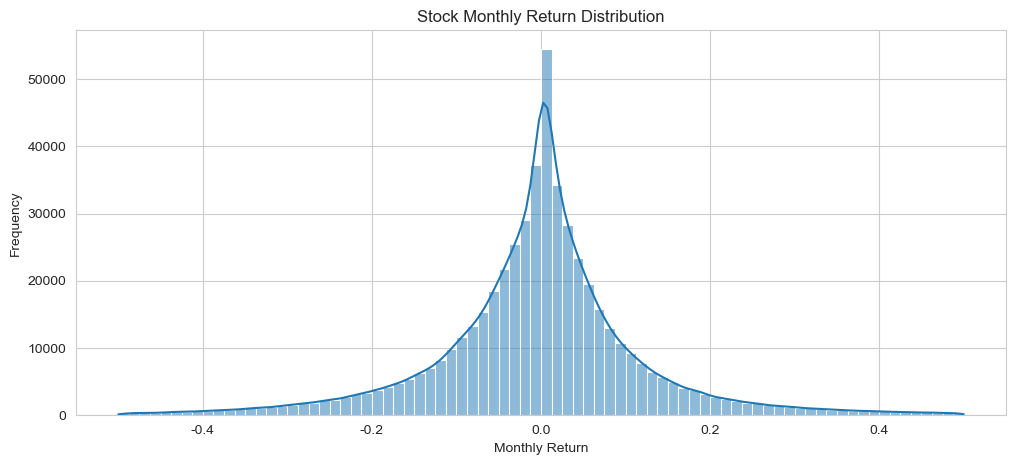

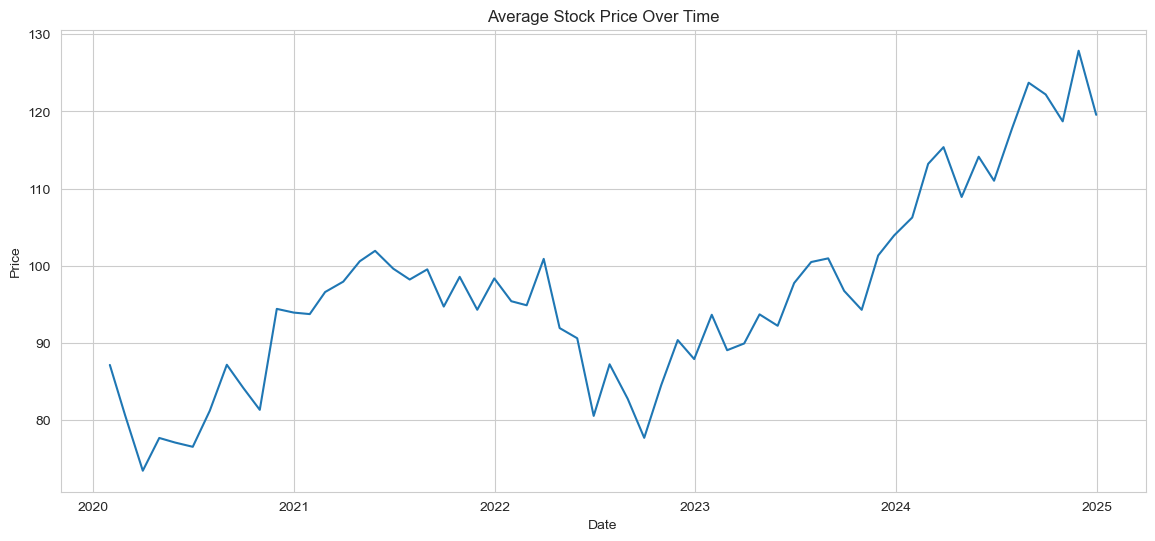

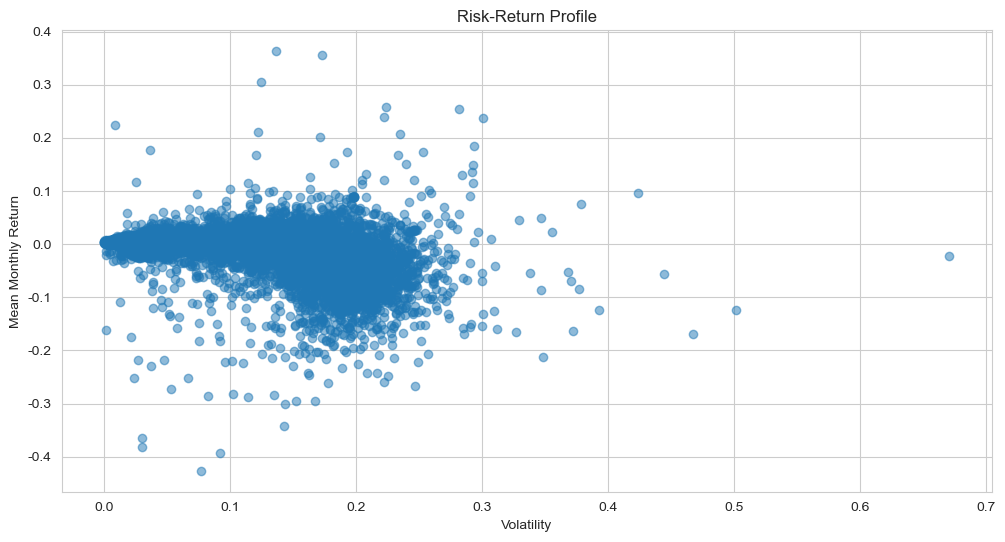

In [9]:
# 数据清洗
df['date'] = pd.to_datetime(df['date'])
df['prc'] = df['prc'].abs()
df = df.dropna(subset=['ret'])
df = df[(df['ret'] > -0.5) & (df['ret'] < 0.5)]
df = df.sort_values(['permno', 'date'])

# 数据探索
print(df.isnull().sum())
print(df.describe())

# 绘图1 收益率分布
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
sns.histplot(df['ret'], bins=80, kde=True)
plt.title('Stock Monthly Return Distribution')
plt.xlabel('Monthly Return')
plt.ylabel('Frequency')
plt.show()

# 绘图2 平均股价时间趋势
df_avg_price = df.groupby('date')['prc'].mean()
plt.figure(figsize=(14,6))
plt.plot(df_avg_price)
plt.title('Average Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# 绘图3 风险收益特征
stock_stats = df.groupby('permno')['ret'].agg(mean_return='mean', volatility='std').reset_index()
plt.figure(figsize=(12,6))
plt.scatter(stock_stats['volatility'], stock_stats['mean_return'], alpha=0.5)
plt.title('Risk-Return Profile')
plt.xlabel('Volatility')
plt.ylabel('Mean Monthly Return')
plt.grid(True)
plt.show()